Note we utilize duckdb view chains to modify the large dataset

If you are unfamiliar with duckdb please refer to the documentation: https://duckdb.org/docs/stable/clients/python/overview

DOWNLOAD: This file must be moved from Snellius to its corresponding local folder. Ignore this tag for local processing purposes.

# Data Loading

In [1]:
snellius = True  # Set to True if running on Snellius, False for local development
partition = "operational_features_process" if snellius else "subset_week"

In [2]:
create_dataset = True  # Set to True to create the dataset, False to skip for faster execution
check_stats = False  # Set to True to display intermediate stats, False to skip for faster execution
create_intermediate_datasets = False

In [3]:
rstats = (snellius is True) and (check_stats is True) #run stats
cdata_new = (snellius is True) and (create_dataset is True) # create data
cdata_old = (cdata_new is True) and (create_intermediate_datasets is True) 

## Set root folder path 

In [ ]:
# pip install any missing packages before running the notebook
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
import os
from pathlib import Path

if snellius is False:
    # Change later to snellius $HOME or whatever folder you want to work in
    target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

    # Check if it exists before moving
    if target_root.exists():
        os.chdir(target_root)
        print(f"✅ Success! Moved to: {Path.cwd()}")
    else:
        print(f"❌ Error: The folder '{target_root}' does not exist.")


## Snellius Setup
We can directly read and write files to our personal $HOME node on snellius (instead of the tmpdir and copying back and forth)

To run this notebook, utilize the same project structure from /Bao onwards

First transfer files to Snellius (vscode) terminal:
scp -r ./MSc-Thesis/Bao/X username@snellius.surf.nl:~/Project_folder/X
where X = {all_code, downloads, media} folders

(or gitbash):
rsync -avP ./MSc-Thesis/Bao/{all_code,downloads,media} name@snellius.surf.nl:~/NS_Thesis/

On Snellius:
setup environment.yml
run sbatch InstallEnv.job
run the corresponding .job

In [ ]:
if snellius is True:
    from pathlib import Path
    # Get the home directory path object
    home_dir = Path.home() 

    # Build a path to your code
    target_root = home_dir / "NS_Thesis"

    print(target_root)

    # Test writing a file to confirm the path works
    # # 1. Define the path (Home Directory)
    # # On Snellius, this will resolve to /home/jbao
    # file_path = Path.home() / "test_file.txt"

    # # 2. Write a small test message
    # try:
    #     with open(file_path, "w") as f:
    #         f.write("This is a test file to verify the home directory path.\n")
        
    #     print(f"✅ Success! File saved to: {file_path}")
    #     print("⚠️  Reminder: Do not save large datasets here (16GB Quota).")
    # except Exception as e:
    #     print(f"❌ Error: Could not write to file. {e}")

/home/jbao/NS_Thesis


## Set paths

In [ ]:
project_root = target_root

root_folder =  project_root / "downloads/data/raw/"
filtered_output_root_folder = project_root / "downloads/data/filtered/"

services_path = root_folder / "NS-services/services_merged_all_ns_only.parquet"
disruptions_path = root_folder / "NS-disruptions/disruptions_merged_all.parquet"
stations_path = root_folder / "NS-stations/stations-2023-09-nl.csv" #duckdb seem to handle 'NA' station code properly, so load the original file
station_distances_path = root_folder / "NS-tariff-distances/tariff-distances-2022-01.csv" #probably not used in eda, might only be useful for graph edges feature
stations_connections_path = root_folder / "railway_map/connection_edges.parquet" 

weather_path = root_folder / "weather/weather_merged_all.parquet"
holiday_path = root_folder / "holidays/dutch_holidays_2019_2025.parquet"

media_folder = project_root / "media"
# if not media_folder.exists():
#     media_folder.mkdir()

# 1. Setup paths to iterate over

paths = {
    "Services": services_path,
    "Disruptions": disruptions_path,
    "Stations": stations_path,
    "Station Distances": station_distances_path,
    "Weather": weather_path,
    "Holidays": holiday_path
}


# 2. Paths of filtered datasets (after EDA and cleaning)
aggregated_hourly_path = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"

GRAPH_OUTPUT_DIR = filtered_output_root_folder / "graph_features_output"
os.makedirs(GRAPH_OUTPUT_DIR, exist_ok=True)

graph_features_path = filtered_output_root_folder / "final_aggregated/services_hourly_graph_features.parquet"

In [ ]:
## Connect to database
db_name = 'main_thesis_data.duckdb'

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database='main_thesis_data.duckdb') 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
    con.execute("SET memory_limit='5GB'")   

Does file exist? True


## SAVING CODE

duckdb tables to parquet

In [9]:
# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

## Helper functions

In [ ]:
def check_arrival_delay_distribution(dataset_name):
    print(f"Checking arrival_delay_min distribution for {dataset_name}...")
    ad_distribution_df = con.execute(f"""
        SELECT 
            -- Create the bin floor (0, 100, 200...)
            FLOOR(arrival_delay_min / 100) * 100 AS bin_start,
            
            -- Create a readable label
            CAST(FLOOR(arrival_delay_min / 100) * 100 AS INTEGER) || ' to ' || 
            CAST(FLOOR(arrival_delay_min / 100) * 100 + 100 AS INTEGER) || ' min' AS bin_label,
            
            -- Count services in this bin
            COUNT(*) AS count,
            
            -- Optional: Percentage
            ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM {dataset_name} WHERE arrival_delay_min IS NOT NULL), 4) AS pct
            
        FROM {dataset_name}
        WHERE arrival_delay_min IS NOT NULL
        GROUP BY 1, 2
        ORDER BY 1
    """).df()

    return display(ad_distribution_df)

## Duckdb prep

In [ ]:
# 2. Initialize Disk-Based Database
# This creates a file 'main_thesis_data.duckdb' in your current folder.
# Intermediate calculations (joins/group bys) will spill here instead of crashing RAM.
# con = duckdb.connect(database='main_thesis_data.duckdb') 

# 3. Register Views (Zero-Copy), Run once
# We use VIEWs so we don't duplicate the Parquet data into the .duckdb file.
# DuckDB reads directly from the parquet files on demand.
con.execute(f"CREATE OR REPLACE VIEW raw_services AS SELECT * FROM read_parquet('{services_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_disruptions AS SELECT * FROM read_parquet('{disruptions_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_weather AS SELECT * FROM read_parquet('{weather_path}')")
con.execute(f"CREATE OR REPLACE VIEW stations AS SELECT * FROM read_csv_auto('{stations_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_holidays AS SELECT * FROM read_parquet('{holiday_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_station_distances AS SELECT * FROM read_csv_auto('{station_distances_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_stations_connections AS SELECT * FROM read_parquet('{stations_connections_path}')") # Prob not needed as stations from RdT is pulled from NS API already, but just in case

# Aggregated dataset for graph edges features
con.execute(f"CREATE OR REPLACE VIEW aggregated_hourly AS SELECT * FROM read_parquet('{aggregated_hourly_path}')")
con.execute(f"CREATE OR REPLACE VIEW aggregated_hourly_graph_features AS SELECT * FROM read_parquet('{graph_features_path}')")




# 4. Create CLEAN Views (Logic remains the same, but executed safely)
con.execute("""
    CREATE OR REPLACE VIEW services AS 
    SELECT 
        "Service:RDT-ID" AS service_id,
        "Service:Date" AS service_date,
        "Service:Type" AS train_type,
            
        "Service:Completely cancelled" AS is_completely_cancelled, 
        "Service:Partly cancelled" AS is_partly_cancelled,

        "Stop:Station code" AS station_code,
        "Stop:Station name" AS station_name,
        
        -- Apply Timezone conversion HERE in the SELECT statement
        ("Stop:Arrival time" AT TIME ZONE 'Europe/Amsterdam')::TIMESTAMP AS arrival_time,
        
        "Stop:Arrival delay" AS arrival_delay_min,
        "Stop:Arrival cancelled" AS is_arrival_cancelled,
        
        -- Apply Timezone conversion HERE too
        ("Stop:Departure time" AT TIME ZONE 'Europe/Amsterdam')::TIMESTAMP AS departure_time,
        
        "Stop:Departure delay" AS departure_delay_min,
        "Stop:Departure cancelled" AS is_departure_cancelled,
        
        "Stop:Platform change" AS has_platform_change,
            
    FROM raw_services
""")

print("✅ Table 'services' created with clean names and local timestamps.")

con.execute("""
    CREATE OR REPLACE VIEW disruptions AS 
    SELECT 
        *,
        CASE 
            WHEN rdt_station_codes LIKE '[%]' 
            THEN string_split(trim(rdt_station_codes, '[]'), ', ') 
            ELSE string_split(rdt_station_codes, ',') 
        END AS station_array
    FROM raw_disruptions
""")

print("Disk-based database initialized. Queries will now spill to 'main_thesis_data.duckdb' if needed.")

✅ Table 'services' created with clean names and local timestamps.
Disk-based database initialized. Queries will now spill to 'main_thesis_data.duckdb' if needed.


In [12]:
con.execute("""DESCRIBE aggregated_hourly_graph_features""").df()

,column_name,column_type,null,key,default,extra
0,source,VARCHAR,YES,None,None,None
1,target,VARCHAR,YES,None,None,None
2,service_date,DATE,YES,None,None,None
3,arrival_hour,BIGINT,YES,None,None,None
4,earliest_departure_hour,BIGINT,YES,None,None,None
5,distance,INTEGER,YES,None,None,None
6,total_departure_delay_minutes,DOUBLE,YES,None,None,None
7,avg_departure_delay_minutes,DOUBLE,YES,None,None,None
8,count_delayed_departure_services,BIGINT,YES,None,None,None
9,total_delay_minutes,DOUBLE,YES,None,None,None


## Total services in dataset

Total services ROWCOUNT = 83_816_585

In [ ]:
if rstats:
    display(con.execute("SELECT count(service_id) FROM services").df())

# Processing

## Outliers


In [ ]:
# Checking arrival_delay_min distribution before cancellation penalty application

if rstats:
    check_arrival_delay_distribution("services")

## Preprocess: NA values Cleaning and Handling

### NA values in services meaning

The NA values at arrival and departure columns means there is no arrival or departure scheduled.

In [ ]:
if rstats:
    # Check if there are cases where arrival_delay_min is present but arrival_time is NULL (which would mean that a train was delayed but not scheduled to arrive)
    display(con.execute("""
        SELECT 
            service_id,
            station_name,
            arrival_time,
            arrival_delay_min,
            is_arrival_cancelled
        FROM services
        WHERE 
            arrival_delay_min IS NOT NULL 
            AND arrival_time IS NULL
        LIMIT 20
    """).df())

In [ ]:
if rstats:
    # Query to find "Terminus" stops (Arrival exists, Departure missing)
    df_terminus = con.execute("""
        SELECT 
            service_id,
            station_name,
            arrival_delay_min,
            arrival_time,
            is_arrival_cancelled
        FROM services
        WHERE 
            -- Condition 1: Departure info is missing (OR logic as requested)
            (arrival_time IS NULL OR arrival_delay_min IS NULL OR is_arrival_cancelled IS NULL)
            
            AND 
            
            -- Condition 2: Arrival info is present (OR logic as requested)
            (departure_time IS NOT NULL OR departure_delay_min IS NOT NULL OR is_departure_cancelled IS NOT NULL)
        
        -- Optional: Limit to see a sample first
        LIMIT 20
    """).df()

    display(df_terminus)

#### p.1) Handling NA values
- Remove unscheduled trains (NA at both arrival and departure columns)
- Fill start stations (NA at arrival columns, it never 'arrives' so columns:arrival_time = departure_time, arrival_delay_min = 0, is_arrival_cancelled = FALSE)
- Fill end stations (NA at departure columns, it never 'departs' so columns: departure_time = arrival_time, departure_delay_min = 0, is_departure_cancelled = FALSE)

We note that:

NA values in arrival_time and arrival_delay_min indicate the start of a service.

NA values in departure_time and arrival_delay_min indicate the end of a service. 

A starting station could never have arrival delay as it is already there (IS NA values in arrival columns)

A end station could never have departure delay as will never depart there (IS NA values in departure columns)

By handling the NA values like this we add some 'noise' to our dataset, but it logically follows from the schedule.

##### A) Removing unscheduled services (services with ONLY NA values in both departure and arrival time & delay) (5652 services)

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_scheduled AS 
    SELECT * FROM services
    WHERE NOT (
        arrival_time IS NULL 
        AND departure_time IS NULL 
        AND arrival_delay_min IS NULL
        AND departure_delay_min IS NULL
    )
""")

print("✅ View 'services_scheduled' created (Unscheduled rows hidden).")

✅ View 'services_scheduled' created (Unscheduled rows hidden).


scheduled services ROWCOUNT = 83_810_933

In [ ]:
if rstats:
    display(con.execute("SELECT count(service_id) FROM services_scheduled").df())

##### B) Imputing NA values for arrival columns (8_121_562 services) and departure columns (8_119_198 services)

2364 train services are missing end stations, most likely could be explained by the column "Service:Train number" due to merging (or splitting) of trains.
"A single service may sometimes have multiple train numbers. For example, when a train is split in two parts, or when a train changes a train number on a major station halfway." https://www.rijdendetreinen.nl/en/open-data/train-archive

In [19]:
print(8_121_562 - 8_119_198)

2364


In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_filled AS 
    SELECT 
        * REPLACE (
            -- =========================================================
            -- 1. STRICT Fix for Start Stations (Fill Arrival)
            -- Only runs if ALL 3 arrival columns are NULL
            -- =========================================================
            CASE 
                WHEN arrival_time IS NULL 
                     AND arrival_delay_min IS NULL 
                     AND is_arrival_cancelled IS NULL
                THEN departure_time             -- Action: Fill with Departure
                ELSE arrival_time               -- Action: Keep original (even if NULL)
            END AS arrival_time,

            CASE 
                WHEN arrival_time IS NULL 
                     AND arrival_delay_min IS NULL 
                     AND is_arrival_cancelled IS NULL
                THEN 0                          -- Action: Assume 0 delay
                ELSE arrival_delay_min          -- Action: Keep original
            END AS arrival_delay_min,

            CASE 
                WHEN arrival_time IS NULL 
                     AND arrival_delay_min IS NULL 
                     AND is_arrival_cancelled IS NULL
                THEN FALSE                      -- Action: Assume not cancelled
                ELSE is_arrival_cancelled       -- Action: Keep original
            END AS is_arrival_cancelled,

            -- =========================================================
            -- 2. STRICT Fix for End Stations (Fill Departure)
            -- Only runs if ALL 3 departure columns are NULL
            -- =========================================================
            CASE 
                WHEN departure_time IS NULL 
                     AND departure_delay_min IS NULL 
                     AND is_departure_cancelled IS NULL
                THEN arrival_time               -- Action: Fill with Arrival
                ELSE departure_time             -- Action: Keep original
            END AS departure_time,

            CASE 
                WHEN departure_time IS NULL 
                     AND departure_delay_min IS NULL 
                     AND is_departure_cancelled IS NULL
                THEN 0 
                ELSE departure_delay_min 
            END AS departure_delay_min,

            CASE 
                WHEN departure_time IS NULL 
                     AND departure_delay_min IS NULL 
                     AND is_departure_cancelled IS NULL
                THEN FALSE 
                ELSE is_departure_cancelled 
            END AS is_departure_cancelled
        )
    FROM services_scheduled
""")

print("✅ View 'services_filled' created. Strict imputation applied.")

✅ View 'services_filled' created. Strict imputation applied.


#### p.2) Arrival Delay of Cancellations

We set an arrival delay penalty of 30 min to partly cancelled services and 60 min to completely cancelled services

Cancellations as % of all services

In [ ]:
if rstats:
    con.execute("""
        SELECT 
            -- Total
            count(*) as total_services,
            
            -- Counts
            count(*) FILTER (WHERE is_partly_cancelled OR is_completely_cancelled) as total_all_cancelled_services,
            count(*) FILTER (WHERE is_partly_cancelled AND NOT is_completely_cancelled) as count_partly_cancelled,
            count(*) FILTER (WHERE is_completely_cancelled) as count_completely_cancelled,
            count(*) FILTER (WHERE is_partly_cancelled AND is_completely_cancelled) as count_both_cancelled,
                
                
            -- Percentages (Logic repeated)
            round(
                total_all_cancelled_services / total_services * 100.0, 
            2) as pct_all_cancelled,

            round(
                count_partly_cancelled / total_services * 100.0, 
            2) as pct_partly_cancelled,

            round(
                count_completely_cancelled / total_services * 100.0, 
            2) as pct_completely_cancelled,
                
            round(
                count_both_cancelled / total_services * 100.0,
            2) as pct_both_cancelled
            
        FROM services_filled
    """).df()

Cancellations as % of all CANCELLED services

In [ ]:
if rstats:
    con.execute("""
        SELECT 
            -- Total
            -- count(*) as total_services,
            
            -- Counts
            count(*) FILTER (WHERE is_partly_cancelled OR is_completely_cancelled) as total_all_cancelled_services,
            count(*) FILTER (WHERE is_partly_cancelled AND NOT is_completely_cancelled) as count_partly_cancelled,
            count(*) FILTER (WHERE is_completely_cancelled) as count_completely_cancelled,
            count(*) FILTER (WHERE is_partly_cancelled AND is_completely_cancelled) as count_both_cancelled,
                
            -- Percentages (Logic repeated)
            round(
                total_all_cancelled_services / total_all_cancelled_services * 100.0, 
            2) as pct_all_cancelled,

            round(
                count_partly_cancelled / total_all_cancelled_services * 100.0, 
            2) as pct_partly_cancelled,

            round(
                count_completely_cancelled / total_all_cancelled_services * 100.0, 
            2) as pct_completely_cancelled,
            
            round(
                count_both_cancelled / total_all_cancelled_services * 100.0,
            2) as pct_both_cancelled
        
            
        FROM services_filled
    """).df()

9.3% (7_813_345 million services) of all services (83_810_933) are affected by cancellations

out of all cancelled services

76.1% is partly cancelled

23.9% is completely cancelled

In [23]:
print(7_813_345 / 83_810_933 * 100)

9.322584441340128


In [ ]:
if rstats:
    con.execute("""
        SELECT 
            -- Total Cancelled Rows
            count(*) as total_cancelled,
            
            -- 1. Delay >= 60 mins
            count(*) FILTER (WHERE arrival_delay_min >= 60) as count_gt_60,
            round(count(*) FILTER (WHERE arrival_delay_min >= 60) * 100.0 / count(*), 2) as pct_gt_60,

            -- 2. Delay >= 30 < 60 mins
            count(*) FILTER (WHERE arrival_delay_min >= 30 AND arrival_delay_min < 60) as count_gt_30,
            round(count(*) FILTER (WHERE arrival_delay_min >= 30 AND arrival_delay_min < 60) * 100.0 / count(*), 2) as pct_gt_30,
            
            -- 2. Delay > 0 < 30 mins
            count(*) FILTER (WHERE arrival_delay_min > 0 AND arrival_delay_min < 30) as count_gt_1,
            round(count(*) FILTER (WHERE arrival_delay_min > 0 AND arrival_delay_min < 30) * 100.0 / count(*), 2) as pct_gt_1,

            -- 3. Delay <= 0
            count(*) FILTER (WHERE arrival_delay_min <= 0) as count_eq_0,
            round(count(*) FILTER (WHERE arrival_delay_min <= 0) * 100.0 / count(*), 2) as pct_eq_0,
                
        FROM services_filled
        WHERE 
            -- Focus only on cancelled services
            (is_partly_cancelled = TRUE OR is_completely_cancelled = TRUE)
    """).df()

##### p.2A) Set Arrival Delay Penalty for both completely and partly cancelled services (changes the delayed classification distribution)

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_penalty AS 
    SELECT * REPLACE (
        CASE
            WHEN is_completely_cancelled = TRUE THEN 60
            WHEN is_partly_cancelled = TRUE THEN 30
            ELSE arrival_delay_min
        END AS arrival_delay_min
    )
    FROM services_filled
""")

# Verify the "overwrite" worked
if rstats:
    con.execute("SELECT is_completely_cancelled, arrival_delay_min FROM services_penalty WHERE is_completely_cancelled = TRUE LIMIT 5").df()

In [ ]:
if rstats:
    display(con.execute("SELECT * FROM services_penalty LIMIT 10").df())

could also exclude all services with cancellations from the services dataset with the commented code below

In [ ]:
# con.execute("""
#     CREATE OR REPLACE VIEW services_penalty AS 
#     SELECT * FROM services_filled
#     WHERE 
#         -- Exclude cancelled arrivals
#         is_arrival_cancelled IS NOT TRUE
        
#         -- Exclude cancelled departures
#         AND is_departure_cancelled IS NOT TRUE
# """)

# # Quick verification: Check how many rows remain
# print(con.execute("SELECT count(*) FROM services_penalty").fetchone()[0])

In [ ]:
if snellius is True:
    # Checking arrival_delay_min distribution after penalty application
    check_arrival_delay_distribution("services_penalty")

Checking arrival_delay_min distribution for services_penalty...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bin_start,bin_label,count,pct
0,-100.0,-100 to 0 min,334,0.0004
1,0.0,0 to 100 min,83809448,99.9982
2,100.0,100 to 200 min,1017,0.0012
3,200.0,200 to 300 min,72,0.0001
4,300.0,300 to 400 min,13,0.0000
5,400.0,400 to 500 min,1,0.0000
6,500.0,500 to 600 min,9,0.0000
7,600.0,600 to 700 min,13,0.0000
8,900.0,900 to 1000 min,9,0.0000
9,1400.0,1400 to 1500 min,17,0.0000


## Transformation 1: adding 'to stations' columns to services dataset

Each service has atleast two rows: the departure (current Stop:Station, i.e. from station) and arrival (to station inferred from sorting the service line and time). 

source = departure station

target = arrival station

In [ ]:
# ==========================================
# STEP 2: Create Edges (Window Functions)
# ==========================================
# We materialize this as a TABLE to compute the expensive window functions once.
con.execute("""
    CREATE OR REPLACE VIEW services_with_edges AS 
    SELECT 
        *,
        -- From station is just the current row's station code
        station_code AS source,
            
        -- 1. Where are we going next? Get Destination (Next Row)
        LEAD(station_code) OVER (
            PARTITION BY service_id 
            ORDER BY COALESCE(departure_time, arrival_time) ASC
        ) AS target

    FROM services_penalty
""")
print("✅ Layer 2: Added Edge columns.")

✅ Layer 2: Added Edge columns.


Edges = 2931 (takes ~1min locally)

In [ ]:
if rstats:
    display(con.execute("""
        SELECT count(*) AS unique_edges
        FROM (
            SELECT DISTINCT source, target 
            FROM services_with_edges
            WHERE target IS NOT NULL
        )
    """).df())

## Transformation 2: Stations
We keep the stations dataset as ground truth for which stations exist (in the netherlands) and drop services with other stations

### A) Add station distances feature

In [ ]:
# ==========================================
# STEP 1: Flatten distance matrix dataset
# ==========================================
con.execute("""
    CREATE OR REPLACE VIEW station_distances_long AS 
    SELECT 
        Station AS source,          -- Rename 'Station' to 'source' for clarity
        target_station AS target, 
        CAST(distance AS INTEGER) AS distance
    FROM (
        UNPIVOT raw_station_distances
        ON COLUMNS(* EXCLUDE (Station))
        INTO
            NAME target_station
            VALUE distance
    )
    -- Filter 1: Explicitly remove the known garbage values
    WHERE distance NOT IN ('?', 'XXX')
    
    -- Filter 2: (Optional but Safer) Ensure only valid numbers remain
    -- AND TRY_CAST(distance AS INTEGER) IS NOT NULL
""")

if rstats:
    # Let's verify the columns first to be safe:
    print("Unpivoted columns:", con.execute("DESCRIBE station_distances_long").df()['column_name'].tolist())

Following 2 stations from the distance connection matrix were not in stations

LEER
WR

In [ ]:
if rstats:
    con.execute("""
        -- 1. Get ALL stations from the matrix
        WITH matrix_stations AS (
            SELECT TRIM(source) AS station FROM station_distances_long
            UNION 
            SELECT TRIM(target) AS station FROM station_distances_long
        )
        
        -- 2. "Subtract" the official list
        SELECT station AS not_in_stations FROM matrix_stations
        
        EXCEPT 
        
        SELECT TRIM(code) FROM stations
    """).df()

In [ ]:
if rstats:
    con.execute("""
        SELECT TRIM(code) AS not_in_distances
        FROM stations
        
        EXCEPT 
        
        -- Subtract all stations found in the matrix
        (
            SELECT TRIM(source) FROM station_distances_long
            UNION 
            SELECT TRIM(target) FROM station_distances_long
        )
    """).df()

In [ ]:
# ==========================================
# STEP 2: Join Distances
# ==========================================
con.execute("""
    CREATE OR REPLACE VIEW services_edges_distances AS 
    SELECT 
        e.*, 
        d.distance AS distance
    FROM services_with_edges e
    LEFT JOIN station_distances_long d
        ON e.source = d.source 
        AND e.target = d.target
""")

print("✅ Layer 2A: Distances joined.")

✅ Layer 2A: Distances joined.


330 edges missing distances i.e. not in stations distances dataset ~(1 min)

In [ ]:
if rstats:
    # Check for "Orphan Edges" (Edges that exist but have no distance)
    orphan_edges = con.execute("""
        SELECT DISTINCT source, target 
        FROM services_edges_distances
        WHERE 
            target IS NOT NULL      -- Ignore the last station of a trip (it has no target)
            AND distance IS NULL    -- Capture where the join failed
    """).df()

    if not orphan_edges.empty:
        print(f"⚠️ Warning: {len(orphan_edges)} routes are missing distance data.")
        display(orphan_edges.head())
    else:
        print("✅ Success: All edges have a corresponding distance.")

### B) Services with valid stations

In [ ]:
# ==========================================
# Filter Invalid Rows
# ==========================================
con.execute("""
    CREATE OR REPLACE VIEW services_valid AS 
    SELECT * FROM services_edges_distances
    WHERE 
        -- 1. Distance must be known (removes missing edges from the Matrix)
        distance IS NOT NULL
        
        -- 2. Source must be in the official station list
        AND (source IN (SELECT code FROM stations)
        
        -- 3. Target must be in the official station list
        AND target IN (SELECT code FROM stations))
""")

print("✅ Layer 2B: Filtered services to valid edges only.")

✅ Layer 2B: Filtered services to valid edges only.


Valid services ROWCOUNT = 
75_303_052 

In [ ]:
if snellius is True:
    con.sql("SELECT count(*) FROM services_valid").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     75303052 │
└──────────────┘



In [ ]:
if rstats:
    check_arrival_delay_distribution("services_valid")

### Service delay bins (figures)

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW delay_bins AS
    SELECT 
        -- Create the bins on the fly (or use your view)
        CASE 
            WHEN arrival_delay_min <= 0 THEN 'On Time (inf, 0]'
            WHEN arrival_delay_min < 30 THEN 'Small Delay (0, 30)'
            WHEN arrival_delay_min < 60 THEN 'Medium Delay [30, 60)'
            ELSE 'Large Delay [60, inf)'
        END AS delay_category,
        
        -- Helper column for sorting the chart correctly
        CASE 
            WHEN arrival_delay_min <= 0 THEN 1
            WHEN arrival_delay_min < 30 THEN 2
            WHEN arrival_delay_min < 60 THEN 3
            ELSE 4
        END AS sort_order,

        -- Count services in each bin
        COUNT(*) as count
    FROM services_valid
    WHERE arrival_delay_min IS NOT NULL
    GROUP BY 1, 2
    ORDER BY sort_order
""")

In [40]:
# binned_data_output_path = filtered_output_root_folder / "full_services_dataset/service_delay_bins.parquet"

In [41]:
# con.execute(f"COPY delay_bins TO '{binned_data_output_path}' (FORMAT PARQUET)")
# print("Done! Saved as ", binned_data_output_path)

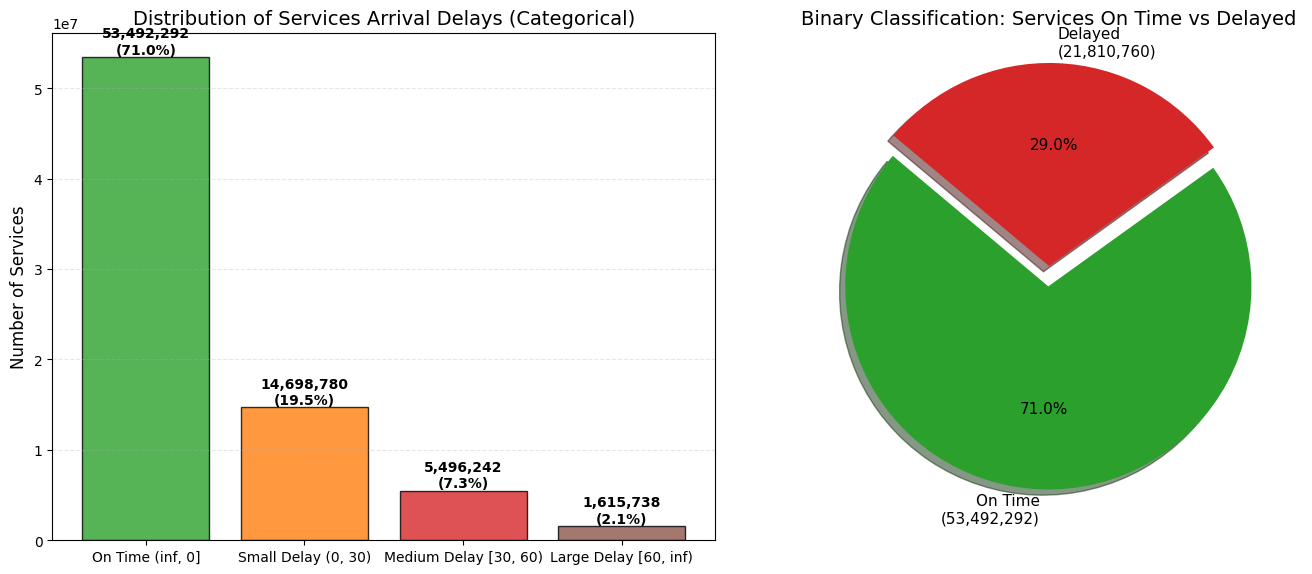

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Data
binned_data_file = filtered_output_root_folder / "full_services_dataset/delay_bins.parquet"
df_bins = pd.read_parquet(binned_data_file)

# 2. Calculate Totals (Needed for %)
total_services = df_bins['count'].sum()
on_time_count = df_bins[df_bins['sort_order'] == 1]['count'].sum()
delayed_count = df_bins[df_bins['sort_order'] > 1]['count'].sum()

# 3. Setup the Plot Area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Multi-Class Bar Chart ---
bars = ax1.bar(
    df_bins['delay_category'], 
    df_bins['count'], 
    color=['#2ca02c', '#ff7f0e', '#d62728', '#8c564b'], 
    edgecolor='black', 
    alpha=0.8
)

ax1.set_title('Distribution of Services Arrival Delays (Categorical)', fontsize=14)
ax1.set_ylabel('Number of Services', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels AND percentages on top of bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_services) * 100  # Calculate %
    
    # Format: "1,234 \n (12.5%)"
    label_text = f'{int(height):,}\n({percentage:.1f}%)'
    
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             label_text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Plot 2: Binary Pie Chart ---
labels = [f'On Time\n({on_time_count:,})', f'Delayed\n({delayed_count:,})']
sizes = [on_time_count, delayed_count]
colors = ['#2ca02c', '#d62728'] 
explode = (0, 0.1) 

ax2.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 11})
ax2.set_title('Binary Classification: Services On Time vs Delayed', fontsize=14)

# 4. Save and Show
plt.tight_layout()
# plt.savefig(f'{media_folder}/delay_classification_plots.png')
# print("✅ Plots saved as 'delay_classification_plots.png'")

## Transformation 3: Hourly Aggregation of Trajectories 

Reclassification label: We aggregate the services trajectories into hourly bins (
CLASSIFICATION LABEL IN FEATURE ENGINEERING)

Using the AVERAGE arrival delay of the services on the trajectories in that HOUR to classify 

 binary (no delay or delayed)
 
 and multiclassification (inf <=0], (0 < 30), [30 < 60), [60 < inf)

(Merel's and Jonathan paper utilized the COUNT of services on a trajectory for their classification label?) -> Lei's original work was based on edge removal classification based on actual edges that were present at month M but not M+1 as ground truth

Delay classification is performance based (Passenger experience): under these topological conditions will a train on a trajectory to what extent will the train be delayed?
 
Lei's: Edge Removal, infrastructural failure "Under these conditions, does the connection physically exist?"

Adding the following information per trajaectory:
- hourly network topology features (node level)
- holiday feature (flag)
- average of two stations weather features (weather features are recorded at the beginning of an hour, ensuring no leakage e.g. services at 18:XX utilize actual observed weather features of 18:00)
- target (delay classification) column 


In [43]:
# # Inspecting columns to keep/drop for graph features
# display(con.execute("""
#     SELECT column_name 
#     FROM (DESCRIBE services_valid)
# """).df())

### Create clean hourly services dataset (run once)

DOWNLOAD: downloads/data/filtered/final_aggregated/services_hourly.parquet

hourly aggregated services (NO TIME SERIES) ROWCOUNT = 26_977_795

26_977_895

CHECK HERE ATM

In [ ]:
if snellius is True:
    con.execute("""
        CREATE OR REPLACE TABLE services_hourly_agg AS 
        SELECT 
            -- === 1. GROUPING KEYS ===
            source,
            target,
            service_date,
            
            -- Group ONLY by Arrival Hour
            EXTRACT(hour FROM arrival_time) AS arrival_hour,
            
            -- === 2. EARLIEST DEPARTURE ===
            -- Since we aren't grouping by this, we must aggregate it.
            -- MIN() picks the earliest departure hour
            -- (e.g., if 3 trains arrive at 10:00, and 2 departed at 09:00 and 1 at 08:00, this returns 08)
            MIN(EXTRACT(hour FROM departure_time)) AS earliest_departure_hour,

            -- === 3. STATIC FEATURES ===
            FIRST(distance) AS distance,
            
            -- === 4. DEPARTURE STATS ===
            SUM(departure_delay_min) AS total_departure_delay_minutes,
            ROUND(AVG(departure_delay_min), 2) AS avg_departure_delay_minutes,
            COUNT(*) FILTER (WHERE departure_delay_min > 0) AS count_delayed_departure_services,
            
            -- === 5. ARRIVAL STATS ===
            SUM(arrival_delay_min) AS total_delay_minutes,
            ROUND(AVG(arrival_delay_min), 2) AS avg_delay_minutes,
            COUNT(*) FILTER (WHERE arrival_delay_min > 0) AS count_delayed_services,
            
            -- === 6. FEATURE COUNTS ===
            COUNT(*) AS total_services,
            
            -- Ratio: Departure Delays
            ROUND(COUNT(*) FILTER (WHERE departure_delay_min > 0) * 1.0 / NULLIF(COUNT(*), 0), 4) AS ratio_departure_delayed,
            
            -- Ratio: Arrival Delays
            ROUND(COUNT(*) FILTER (WHERE arrival_delay_min > 0) * 1.0 / NULLIF(COUNT(*), 0), 4) AS ratio_arrival_delayed,
            
            -- Platform Changes
            COUNT(*) FILTER (WHERE has_platform_change IS TRUE) AS count_platform_changes,
            
            -- Train Types
            histogram(train_type) AS train_type_counts
            
        FROM services_valid
        -- Group by Source (1), Target (2), Date (3), and Arrival Hour (4)
        GROUP BY 1, 2, 3, 4
    """)
    print("✅ Aggregated table 'services_hourly_agg' created.")

if cdata_new:
    aggregated_path = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
    con.execute(f"COPY services_hourly_agg TO '{aggregated_path}' (FORMAT PARQUET)")
    print("Done! Saved as ", aggregated_path)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Aggregated table 'services_hourly_agg' created.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Saved as  /home/jbao/NS_Thesis/downloads/data/filtered/final_aggregated/services_hourly.parquet


# Feature Engineering


## Network Topology (Graph) Features 

### Calculate graph features
(Brent's Disruptions adaptation & optimized)

Graph structure of Stations (nodes) remained consistent for all graphs in prior work (brent), as he utilized the stations of the whole dataset to create the daily graphs (this result in including stations that are not connected, so he only alternated the graph structure in edges i.e. the connectivity)

-> we only create a graph that is connected (hourly stations), as total_services is >= 1, which exclude stations that are do not have service in that hour from the graph (i.e. they do not exist as nodes) essentially alternating the graph structure (both nodes and edges connectivity). 

We also return None for hourly 

Feature we utilize now: source, target, weight (total_services_hour)

Could probably utilize lagged features (t-1) for features of t
total_delay_minutes	
avg_delay_minutes
count_delayed_services 
count_platform_changes

In [ ]:
# 2. Get all valid Date-Hour combinations first
print("Fetching time slots...")
time_slots = con.execute(f"""
    SELECT DISTINCT service_date, arrival_hour 
    FROM aggregated_hourly
    ORDER BY 1, 2
""").fetchall()

print(f"✅ Found {len(time_slots)} hourly slots to process.")

# 3. Initialize Storage
# Key will be tuple: (datetime.date(2023, 1, 1), 8)
hourly_node_features = {}
hourly_edge_features = {}

# 4. Helper: Build Graph for One Hour
def get_hourly_graph(date_val, hour_val):
    query = f"""
        SELECT 
            source, 
            target,
            total_services as weight,  -- 'weight' for NetworkX
            distance
        FROM aggregated_hourly
        WHERE service_date = '{date_val}' 
          AND arrival_hour = {hour_val}
    """
    df = con.execute(query).df()
    
    if df.empty:
        return None

    # Fast Bulk Loading
    G = nx.from_pandas_edgelist(
        df, 
        source='source', 
        target='target', 
        edge_attr=['weight', 'distance'], 
        create_using=nx.DiGraph()
    )
    return G

# 5. Helper: Extract Graph Features
def extract_graph_features(G):
    # --- Node Features (Directed) ---
    n_feats = {}
    for node in G.nodes():
        deg = G.degree(node)
        # Weighted Degree (In + Out)
        w_deg = G.in_degree(node, weight='weight') + G.out_degree(node, weight='weight')
        
        # Avg Distance (Safe division)
        # # We look at outgoing edges for distance
        # total_dist = sum(d['distance'] for _, _, d in G.out_edges(node, data=True))
        # avg_dist = total_dist / G.out_degree(node) if G.out_degree(node) > 0 else 0

        # 1. Avg Distance of trains LEAVING here (Out-degree)
        out_edges = list(G.out_edges(node, data='distance'))
        avg_dist_out = sum(d for _, _, d in out_edges) / len(out_edges) if out_edges else 0

        # 2. Avg Distance of trains ARRIVING here (In-degree)
        in_edges = list(G.in_edges(node, data='distance'))
        avg_dist_in = sum(d for _, _, d in in_edges) / len(in_edges) if in_edges else 0
        
        n_feats[node] = {
            'degree': deg,
            'weighted_degree': w_deg,
            'avg_distance': avg_dist_in + avg_dist_out  # Total avg distance (In + Out)
        }

    # --- Edge Features (Undirected for Topology Metrics) ---
    # We create the undirected view ONCE per graph, not per edge
    G_undir = G.to_undirected()
    
    e_feats = {}
    for u, v, data in G.edges(data=True):
        # Common Neighbors
        cn = list(nx.common_neighbors(G_undir, u, v))
        
        # Calculate complex metrics safely
        try:
            # Note: These return iterators, so we list() them and grab the score
            jaccard = list(nx.jaccard_coefficient(G_undir, [(u, v)]))[0][2]
            adamic = list(nx.adamic_adar_index(G_undir, [(u, v)]))[0][2]
            # Resource allocation is very similar to Adamic, might be redundant
            res_alloc = list(nx.resource_allocation_index(G_undir, [(u, v)]))[0][2]
        except:
            jaccard, adamic, res_alloc = 0, 0, 0

        e_feats[(u, v)] = {
            'common_neighbors': len(cn),
            'jaccard_coefficient': jaccard,
            'preferential_attachment': G.degree(u) * G.degree(v),
            'adamic_adar_index': adamic,
            'resource_allocation_index': res_alloc,
            'weight': data['weight'],
            'distance': data['distance']
        }
        
    return n_feats, e_feats

Fetching time slots...
✅ Found 52541 hourly slots to process.


### Create hourly graph features (run once, 2h snellius)
DOWNLOAD: (folder) downloads/data/filtered/graph_features_output/

In [ ]:
# import pandas as pd
# import os

# # Configuration
# CHUNK_SIZE = 8760

# # Buffers (Temporary Lists)
# node_buffer = []
# edge_buffer = []
# batch_count = 0

# print(f" Processing {len(time_slots)} hours. Saving to '{GRAPH_OUTPUT_DIR}'...")

# # --- MAIN LOOP ---
# # tqdm gives you a real-time progress bar with ETA
# for i, (date_val, hour_val) in enumerate(time_slots):
    
#     # A. Build Graph
#     G = get_hourly_graph(date_val, hour_val)
#     if G is None: continue 

#     # B. Extract Features
#     n_feats, e_feats = extract_graph_features(G)
    
#     # C. Flatten & Buffer (Convert Dict -> List of Rows)
#     # Process Node Features
#     for node, feats in n_feats.items():
#         node_buffer.append({
#             'date': date_val,
#             'hour': hour_val,
#             'station': node,
#             **feats  # Unpacks {'degree': 10, ...}
#         })

#     # Process Edge Features
#     for (u, v), feats in e_feats.items():
#         edge_buffer.append({
#             'date': date_val,
#             'hour': hour_val,
#             'source': u,
#             'target': v,
#             **feats # Unpacks {'jaccard': 0.5, ...}
#         })
        
#     # D. Save Checkpoint (Batch Flush)
#     if len(node_buffer) > 0 and (i + 1) % CHUNK_SIZE == 0:
#         # Save Nodes
#         pd.DataFrame(node_buffer).to_parquet(
#             f"{GRAPH_OUTPUT_DIR}/nodes_part_{batch_count}.parquet", index=False
#         )
#         # Save Edges
#         pd.DataFrame(edge_buffer).to_parquet(
#             f"{GRAPH_OUTPUT_DIR}/edges_part_{batch_count}.parquet", index=False
#         )
        
#         # Clear Memory
#         node_buffer = []
#         edge_buffer = []
#         batch_count += 1

# # E. Final Flush (Save whatever is left)
# if node_buffer:
#     pd.DataFrame(node_buffer).to_parquet(f"{GRAPH_OUTPUT_DIR}/nodes_part_{batch_count}.parquet", index=False)
#     pd.DataFrame(edge_buffer).to_parquet(f"{GRAPH_OUTPUT_DIR}/edges_part_{batch_count}.parquet", index=False)

# print("✅ Done! Data saved to parquet files.")

### Join graph features with services (run once)

We read this back in as aggregated_hourly_graph_features in duckdb

DOWNLOAD: downloads/data/filtered/final_aggregated/services_hourly_graph_features.parquet

We merge by the following:
Join NODES (graph_nodes) on 
hour = arrival_hour
date = service_date
station = source

EDGES (graph_edges) on
hour = arrival_hour
date = service_date
source = source
target = target
drop distance
drop weight

In [47]:
graph_nodes_path = str(GRAPH_OUTPUT_DIR / "nodes_part_*.parquet")
graph_edges_path = str(GRAPH_OUTPUT_DIR / "edges_part_*.parquet")

# Load into DuckDB Views
con.execute(f"CREATE OR REPLACE VIEW graph_nodes AS SELECT * FROM read_parquet('{graph_nodes_path}')")
con.execute(f"CREATE OR REPLACE VIEW graph_edges AS SELECT * FROM read_parquet('{graph_edges_path}')")

# Sanity Check: Verify we actually found files and loaded rows
print("✅Done loading graph features into duckdb!")

✅Done loading graph features into duckdb!


In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_hourly_graph_features AS
    SELECT 
        -- 1. Base Table (The core service info)
        base.*,
        
        -- 2. SOURCE Node Features (Origin Context)
        src.degree              AS src_degree,
        src.weighted_degree     AS src_weighted_degree,
        src.avg_distance        AS src_avg_distance,
        
        -- 3. TARGET Node Features (Destination Context)
        tgt.degree              AS tgt_degree,
        tgt.weighted_degree     AS tgt_weighted_degree,
        tgt.avg_distance        AS tgt_avg_distance,

        -- 4. EDGE Features (The Connection Context)
        e.common_neighbors,
        e.jaccard_coefficient,
        e.preferential_attachment,
        e.adamic_adar_index,
        e.resource_allocation_index
        -- Note: We drop 'weight' and 'distance' from here as they are redundant or raw
        
    FROM aggregated_hourly base
    
    -- Join A: Connect Source Station (Node) Features
    LEFT JOIN graph_nodes src 
        ON base.service_date = src.date 
        AND base.arrival_hour = src.hour
        AND base.source = src.station
        
    -- Join B: Connect Target Station (Node) Features
    LEFT JOIN graph_nodes tgt
        ON base.service_date = tgt.date 
        AND base.arrival_hour = tgt.hour
        AND base.target = tgt.station

    -- Join C: Connect the Edge (Route) Features
    LEFT JOIN graph_edges e
        ON base.service_date = e.date 
        AND base.arrival_hour = e.hour
        AND base.source = e.source
        AND base.target = e.target
""")

print("✅ View 'services_hourly_graph_features' created successfully.")

# Save services with hourly graph features
# Save as parquet file 
if cdata_new:
    graph_features_output_path = filtered_output_root_folder / "final_aggregated/services_hourly_graph_features.parquet"
    con.execute(f"COPY services_hourly_graph_features TO '{graph_features_output_path}' (FORMAT PARQUET)")
    print("Done! Saved as ", graph_features_output_path)

✅ View 'services_hourly_graph_features' created successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Saved as  /home/jbao/NS_Thesis/downloads/data/filtered/final_aggregated/services_hourly_graph_features.parquet


## Weather features

We conservatively add hourly weather features, as the dataset is a historical dataset (actual weather values).
For example a service has departure time of (18:XX) and arrival time (19:XX), we add weather features based on the scheduled departure time, ensuring no data leakage from the future. 

Note could also use predicted weather features instead of historical weather features known at time x

In [ ]:
# 1. Create a clean hourly weather view
con.execute("""
    CREATE OR REPLACE VIEW hourly_weather_features AS
    SELECT 
        -- Extract Date and Hour from the timestamp
        CAST(time AS DATE) AS weather_date,
        EXTRACT(HOUR FROM time) AS weather_hour,
        station_code,
        
        -- Select the specific features you requested
        temperature_2m,
        rain,
        snowfall,
        snow_depth,
        wind_speed_10m,
        wind_gusts_10m,
        soil_temperature_0_to_7cm
        
    FROM raw_weather
""")

In [ ]:
# 2. First initial join Weather to the Main Dataset, resulted in additional rows?
con.execute("""
    CREATE OR REPLACE VIEW services_weather_graph_features_merged AS
    SELECT 
        -- 1. All existing Service & Graph columns
        base.*,
        
        -- 2. Weather Features (prefixed for clarity)
        w.temperature_2m,
        w.rain,
        w.snowfall,
        w.snow_depth,
        w.wind_speed_10m,
        w.wind_gusts_10m,
        w.soil_temperature_0_to_7cm
        
    FROM aggregated_hourly_graph_features base
    
    -- Join Weather on Source Station
    LEFT JOIN hourly_weather_features w
        ON base.service_date = w.weather_date
        AND base.earliest_departure_hour = w.weather_hour
        AND base.source = w.station_code
""")

print("✅ View 'services_weather_graph_features_merged' created.")

✅ View 'services_weather_graph_features_merged' created.


In [ ]:
# Check row counts of the base table vs the merged view
count_check = con.execute("""
    SELECT 
        (SELECT COUNT(source) FROM aggregated_hourly_graph_features) as base_count,
        (SELECT COUNT(source) FROM services_weather_graph_features_merged) as merged_count,
        
        -- Calculate the difference
        (SELECT COUNT(source) FROM services_weather_graph_features_merged) - 
        (SELECT COUNT(source) FROM aggregated_hourly_graph_features) as diff
""").df()

print(count_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   base_count  merged_count  diff
0    26977804      26977906   102


Noted an increase of rowcounts at the end, so backtracking rowcounts led us to here. 

It revealed that weather features caused the extra entries in our main dataset. Duplicate entries were discovered. (Lesson learned: do not trust data from API calls blindly, always double check) 

The additional row entries were detected at hour 2 for only certain dates, around the same time annually, for all stations locations to be affected. No NA values. 

Upon further investigation and giving it some thought, it was noted that this was likely caused by daylight saving time.

Since we do not know which of both entries represents 2:00 or 3:00 actual values, we take the average of both. NOTE: interpolation could also likely be performed from 1:00 - 4:00

Duplicate weather entry fix 
(100 rows)

In [ ]:
# Check for duplicates in the weather table on join keys
check_weather = con.execute("""
    SELECT weather_date, weather_hour, station_code, COUNT(*)
    FROM hourly_weather_features
    GROUP BY weather_date, weather_hour, station_code
    HAVING COUNT(*) > 1
""").df()

In [53]:
check_weather['weather_hour'].unique()

array([2])

In [54]:
check_weather['weather_date'].unique()

<DatetimeArray>
['2021-10-31 00:00:00', '2023-10-29 00:00:00', '2020-10-25 00:00:00',
 '2024-10-27 00:00:00', '2022-10-30 00:00:00', '2019-10-27 00:00:00']
Length: 6, dtype: datetime64[us]

In [ ]:
# 1. Get the list of duplicate keys first (as you did)
# We use a CTE or subquery to isolate the keys
query_duplicates = """
    WITH duplicates AS (
        SELECT weather_date, weather_hour, station_code
        FROM hourly_weather_features
        GROUP BY weather_date, weather_hour, station_code
        HAVING COUNT(*) > 1
    )
    
    -- 2. Select ALL columns from the main table where the key matches a duplicate
    SELECT t.*
    FROM hourly_weather_features t
    JOIN duplicates d
        ON t.weather_date = d.weather_date
        AND t.weather_hour = d.weather_hour
        AND t.station_code = d.station_code
    ORDER BY t.station_code, t.weather_date, t.weather_hour
"""

# Display the actual conflicting values
df_duplicate_values = con.execute(query_duplicates).df()
display(df_duplicate_values)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,weather_date,weather_hour,station_code,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm
0,2019-10-27,2,AC,10.887000,0.2,0.0,0.0,19.513195,33.839996,12.237000
1,2019-10-27,2,AC,11.737000,0.7,0.0,0.0,19.386593,36.360001,12.787001
2,2020-10-25,2,AC,15.187000,0.0,0.0,0.0,36.644039,65.520004,13.837001
3,2020-10-25,2,AC,15.337001,0.0,0.0,0.0,37.722775,63.000000,13.887000
4,2021-10-31,2,AC,10.087001,0.0,0.0,0.0,14.825706,25.559999,10.187000
...,...,...,...,...,...,...,...,...,...,...
4759,2022-10-30,2,ZZS,15.400000,0.0,0.0,0.0,11.200571,22.319998,13.850000
4760,2023-10-29,2,ZZS,12.550000,1.8,0.0,0.0,29.686359,55.439999,11.100000
4761,2023-10-29,2,ZZS,11.550000,0.6,0.0,0.0,25.620771,57.959999,10.450000
4762,2024-10-27,2,ZZS,13.950000,0.0,0.0,0.0,8.656858,13.320000,13.150000


In [56]:
df_duplicate_values[df_duplicate_values.isna().any(axis=1)]

,weather_date,weather_hour,station_code,temperature_2m,rain,snowfall,snow_depth,wind_speed_10m,wind_gusts_10m,soil_temperature_0_to_7cm


In [ ]:
# Create a clean, unique weather view
con.execute("""
    CREATE OR REPLACE VIEW v_weather_hourly_clean AS
    SELECT 
        -- Grouping Keys (The unique identifier)
        weather_date,
        weather_hour,
        station_code,
        
        -- Aggregate the features to handle variations
        AVG(temperature_2m) as temperature_2m,
        AVG(rain) as rain,
        AVG(snowfall) as snowfall,
        AVG(snow_depth) as snow_depth,
        AVG(wind_speed_10m) as wind_speed_10m,
        AVG(wind_gusts_10m) as wind_gusts_10m,
        AVG(soil_temperature_0_to_7cm) as soil_temperature_0_to_7cm
        
    FROM hourly_weather_features
    GROUP BY weather_date, weather_hour, station_code
""")

print("✅ Created 'v_weather_hourly_clean' with duplicates merged via Average.")

✅ Created 'v_weather_hourly_clean' with duplicates merged via Average.


In [ ]:
# 2. First initial join Weather to the Main Dataset, resulted in additional rows?
con.execute("""
    CREATE OR REPLACE VIEW services_weather_graph_features_merged AS
    SELECT 
        -- 1. All existing Service & Graph columns
        base.*,
        
        -- 2. Weather Features (prefixed for clarity)
        w.temperature_2m,
        w.rain,
        w.snowfall,
        w.snow_depth,
        w.wind_speed_10m,
        w.wind_gusts_10m,
        w.soil_temperature_0_to_7cm
        
    FROM aggregated_hourly_graph_features base
    
    -- Join Weather on Source Station
    LEFT JOIN v_weather_hourly_clean w
        ON base.service_date = w.weather_date
        AND base.earliest_departure_hour = w.weather_hour
        AND base.source = w.station_code
""")

print("✅ View 'services_weather_graph_features_merged' created.")

✅ View 'services_weather_graph_features_merged' created.


In [ ]:
# Check row counts of the base table vs the merged view
count_check = con.execute("""
    SELECT 
        (SELECT COUNT(source) FROM aggregated_hourly_graph_features) as base_count,
        (SELECT COUNT(source) FROM services_weather_graph_features_merged) as merged_count,
        
        -- Calculate the difference
        (SELECT COUNT(source) FROM services_weather_graph_features_merged) - 
        (SELECT COUNT(source) FROM aggregated_hourly_graph_features) as diff
""").df()

print(count_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   base_count  merged_count  diff
0    26977804      26977804     0


33 missing rows for hour 2

In [ ]:
# Check which hours have the most missing weather data
con.execute("""
    SELECT 
        arrival_hour,
        COUNT(*) as total_rows,
        COUNT(temperature_2m) as rows_with_weather,
        (COUNT(*) - COUNT(temperature_2m)) as missing_matches
    FROM services_weather_graph_features_merged
    GROUP BY arrival_hour
    ORDER BY missing_matches DESC
""").df()

,arrival_hour,total_rows,rows_with_weather,missing_matches
0,2,56634,56601,33
1,1,264100,264098,2
2,0,1149645,1149645,0
3,3,29393,29393,0
4,4,50659,50659,0
5,5,592881,592881,0
6,6,1139500,1139500,0
7,7,1344563,1344563,0
8,8,1411676,1411676,0
9,9,1408043,1408043,0


In [ ]:
# 1. Inspect the content of the duplicates
query_inspection = """
    WITH duplicates_list AS (
        -- Find the (date, hour, station) keys that have > 1 row
        SELECT weather_date, weather_hour, station_code
        FROM hourly_weather_features
        GROUP BY 1, 2, 3
        HAVING COUNT(*) > 1
    )
    
    SELECT 
        t.station_code,
        t.weather_date,
        t.weather_hour,
        -- Select the specific value columns to compare
        t.temperature_2m,
        t.rain,
        t.wind_speed_10m,
        t.snowfall
    FROM hourly_weather_features t
    INNER JOIN duplicates_list d
        ON t.weather_date = d.weather_date
        AND t.weather_hour = d.weather_hour
        AND t.station_code = d.station_code
    ORDER BY t.station_code, t.weather_date, t.weather_hour
"""

# Display the first 20 rows to see the pattern
df_inspection = con.execute(query_inspection).df()
display(df_inspection.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,station_code,weather_date,weather_hour,temperature_2m,rain,wind_speed_10m,snowfall
0,AC,2019-10-27,2,11.737000,0.7,19.386593,0.0
1,AC,2019-10-27,2,10.887000,0.2,19.513195,0.0
2,AC,2020-10-25,2,15.337001,0.0,37.722775,0.0
3,AC,2020-10-25,2,15.187000,0.0,36.644039,0.0
4,AC,2021-10-31,2,10.537001,0.0,15.496736,0.0
5,AC,2021-10-31,2,10.087001,0.0,14.825706,0.0
6,AC,2022-10-30,2,14.987000,0.0,10.464797,0.0
7,AC,2022-10-30,2,14.387000,0.0,10.739832,0.0
8,AC,2023-10-29,2,12.487000,3.5,28.137634,0.0
9,AC,2023-10-29,2,13.037001,1.0,29.620802,0.0


## Holiday features
We add a binary holiday feature flag based and merge on service date

We opt for a BOOLEAN flag (and could adapt per model if necessary)

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_with_holiday AS
    SELECT 
        -- 1. All existing columns
        base.*,
        
        -- 2. Binary Holiday Flag
        -- If the join finds a date, it's NOT NULL -> 1 (Holiday)
        -- If the join finds nothing, it IS NULL -> 0 (Normal Day)
        CASE 
            WHEN h.date IS NOT NULL THEN TRUE
            ELSE FALSE
        END AS is_holiday
        
    FROM services_weather_graph_features_merged base
    
    -- Left Join: Keep all services, attach holiday info if present
    LEFT JOIN raw_holidays h
        ON base.service_date = h.date
""")

print("✅ Added 'is_holiday' column (1/0).")

✅ Added 'is_holiday' column (1/0).


Comment OHE

In [ ]:
# con.execute("""
#     CREATE OR REPLACE VIEW services_with_holiday AS
#     SELECT 
#         -- 1. All existing columns
#         base.*,
        
#         -- 2. Binary Holiday Flag
#         -- If the join finds a date, it's NOT NULL -> 1 (Holiday)
#         -- If the join finds nothing, it IS NULL -> 0 (Normal Day)
#         CASE 
#             WHEN h.date IS NOT NULL THEN 1 
#             ELSE 0 
#         END AS is_holiday
        
#     FROM services_weather_graph_features_merged base
    
#     -- Left Join: Keep all services, attach holiday info if present
#     LEFT JOIN raw_holidays h
#         ON base.service_date = h.date
# """)

# print("✅ Added 'is_holiday' column (1/0).")

## Target Label Class
Binary and Multiclass (4 classes)

Start with binary (as we can just use balanced accuracy metric to compare)


In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW services_labeled AS
    SELECT 
        -- A. All Features
        base.*,
        
        -- B. Binary Target (0 = Early/On Time, 1 = Any Delay)
        CASE 
            WHEN base.avg_delay_minutes > 0 THEN 1 
            ELSE 0 
        END AS target_binary,
        
        -- C. Multiclass Target 
        CASE 
            -- Interval: (-inf, 0]
            WHEN base.avg_delay_minutes <= 0 THEN 0      
            
            -- Interval: (0, 30) 
            WHEN base.avg_delay_minutes < 30 THEN 1      
            
            -- Interval: [30, 60)
            WHEN base.avg_delay_minutes < 60 THEN 2      
            
            -- Interval: [60, inf)
            ELSE 3                                    
        END AS target_multiclass

    FROM services_with_holiday base
""")

print("✅ Final Labeled Dataset Created.")

✅ Final Labeled Dataset Created.


Binary class is somewhat balanced

SERVICES WITH NO DELAY = 54.32

SERVICES WITH DELAY = 45.68



In [ ]:
if rstats:
    print("--- Binary Distribution ---")
    display(con.execute("""
        SELECT 
            target_binary, 
            COUNT(*) as count, 
            ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM services_labeled)), 2) as percentage
        FROM services_labeled
        GROUP BY target_binary
        ORDER BY target_binary
    """).df())

54.32
41.21
3.80
0.68

In [ ]:
if rstats:
    print("--- Multiclass Distribution ---")
    display(con.execute("""
        SELECT 
            target_multiclass, 
            COUNT(*) as count, 
            ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM services_labeled)), 2) as percentage
        FROM services_labeled
        GROUP BY target_multiclass
        ORDER BY target_multiclass
    """).df())

## Unnest train types

In [ ]:
if snellius:
    con.execute("""
        CREATE OR REPLACE TABLE services_train_types AS
        SELECT *,
            COALESCE(train_type_counts['Intercity'], 0)::INT AS count_intercity,
            COALESCE(train_type_counts['Sprinter'], 0)::INT AS count_sprinter,
            (total_services - (COALESCE(train_type_counts['Intercity'], 0) + 
                            COALESCE(train_type_counts['Sprinter'], 0)))::INT AS count_other_trains
        FROM services_labeled
    """)

if rstats:
    # Quick verification of data types
    print("--- Check Train Type Flattening & Types ---")
    display(con.execute("""
        SELECT 
            total_services, 
            count_intercity, 
            count_sprinter, 
            count_other_trains,
            typeof(count_intercity) as type_check
        FROM services_train_types 
        LIMIT 5
    """).df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
if rstats:
    display(con.execute("""DESCRIBE services_train_types""").df())

## Add temporal features

categorical string representation

In [ ]:
if snellius:
    con.execute("""
        CREATE OR REPLACE TABLE services_final AS
        SELECT *,
            strftime(service_date, '%B') AS month_name,
            strftime(service_date, '%A') AS day_name
        FROM services_train_types
    """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# SAVING DATASET

In [ ]:
if cdata_new:
    aggregated_final = filtered_output_root_folder / "final_aggregated/final_dataset.parquet"
    con.execute(f"COPY services_final TO '{aggregated_final}' (FORMAT PARQUET)")
    print("Done! Saved as ", aggregated_final)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Saved as  /home/jbao/NS_Thesis/downloads/data/filtered/final_aggregated/final_dataset.parquet


ROWCOUNT = 26_977_895 ?? -> fixed now

### Add Operational data
#### Rolling feature (avg delay of last 5 recent services of the trajectory)
So we can include a avg service delay and remove the current avg_delay_min

PARTITION BY source, target: Ensures rolling average per trajectory

ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING: It looks at the 5 most recent trains but stops at 1 PRECEDING. If we included the current row, the model would already know the answer for what we're trying to predict (data leakage)

In [71]:
con.execute("""DROP VIEW IF EXISTS final_operational_services""")
con.execute(f"""DROP TABLE IF EXISTS {partition}""")

In [ ]:
project_root = target_root
final_data_filepath = project_root / "downloads/data/filtered/final_aggregated/final_dataset.parquet"
con.execute(f"""
    CREATE OR REPLACE VIEW final_operational_services AS 
    SELECT * FROM read_parquet('{final_data_filepath}')
    ORDER BY service_date, arrival_hour
""")

In [ ]:
if snellius is False:
    con.execute(f"""
        CREATE OR REPLACE TABLE {partition} AS 
        SELECT * FROM final_operational_services 
        WHERE service_date >= '2019-01-01' 
            AND service_date <= '2019-01-02'
    """)	
elif snellius is True: # select all data
    con.execute(f"""
        CREATE OR REPLACE TABLE {partition} AS 
        SELECT * FROM final_operational_services 
        """)

# Verify the dataset count
display(con.execute(f"SUMMARIZE {partition}").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,source,VARCHAR,AC,ZZS,316,None,None,None,None,None,26977804,0.0
1,target,VARCHAR,AC,ZZS,316,None,None,None,None,None,26977804,0.0
2,service_date,DATE,2019-01-01,2024-12-31,2523,2021-12-31 03:13:14.369831,None,2020-07-03,2021-12-30,2023-07-01,26977804,0.0
3,arrival_hour,BIGINT,0,23,24,13.547375761199836,6.0514039483282405,9,14,19,26977804,0.0
4,earliest_departure_hour,BIGINT,0,23,24,13.519306241531002,6.061026607504041,9,14,19,26977804,0.0
5,distance,INTEGER,1,219,136,10.024700490818304,10.885344605934959,3,7,13,26977804,0.0
6,total_departure_delay_minutes,DOUBLE,-62.0,2887.0,348,2.0046194642084285,5.407899931428874,0.0,0.0,2.0,26977804,0.0
7,avg_departure_delay_minutes,DOUBLE,-62.0,1443.0,1527,0.7366564750784977,2.1198889892678054,0.0,0.003284241675055406,0.9904869437128212,26977804,0.0
8,count_delayed_departure_services,BIGINT,0,24,26,0.7434945779871482,0.997035924596642,0,0,1,26977804,0.0
9,total_delay_minutes,DOUBLE,-30.0,2940.0,829,11.159939445034148,33.00775274364003,0.0,0.0,2.999946724535939,26977804,0.0


In [ ]:
# Create a new table with a 'rolling_prev_delay' feature
# Fill the very first trains in the dataset (which have no 'history') with 0 delay 
# (since we have no information about them, this is a reasonable assumption and allows us to keep them in the dataset for modeling)

con.execute(f"""
    CREATE OR REPLACE TABLE training_data_final AS 
    SELECT *,
        COALESCE(
            AVG(avg_delay_minutes) OVER (
                PARTITION BY source, target 
                ORDER BY service_date, arrival_hour
                ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING
            ), 0 
        ) AS rolling_prev_5_avg_delay
    FROM {partition}
""")

# Comment
# Pull the final set for modeling
# df = con.execute("SELECT * FROM training_data_final").df()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
con.execute(f"""
    CREATE OR REPLACE TABLE training_data_event_based AS
    WITH ordered_context AS (
        SELECT 
            *,
            -- 1. Construct a Timestamp (Crucial for calculating precise gaps)
            make_timestamp(
                CAST(extract('year' from service_date) AS INTEGER),
                CAST(extract('month' from service_date) AS INTEGER),
                CAST(extract('day' from service_date) AS INTEGER),
                arrival_hour,
                0, 0
            ) as service_ts,
            
            -- 2. Row Number (Index) per trajectory 
            -- We use this to calculate "How many services ago?"
            ROW_NUMBER() OVER (
                PARTITION BY source, target 
                ORDER BY service_date, arrival_hour
            ) as rn
        FROM training_data_final
    ),
    
    lag_calculations AS (
        SELECT 
            *,
            -- A. The "Gap" (Time since the IMMEDIATE previous service)
            -- Essential for Irregular Time Series: Distinguishes "1 hour later" vs "10 hours later"
            date_diff('minutes', 
                LAG(service_ts) OVER (PARTITION BY source, target ORDER BY service_ts), 
                service_ts
            ) / 60.0 as hours_since_prev_service,

            -- B. Locate the "Last Delayed Event" (Lookback Window)
            -- We look at 'ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING' to prevent leakage
            
            -- 1. Get the Row Number of the last delay
            LAST_VALUE(CASE WHEN target_binary = 1 THEN rn END IGNORE NULLS) OVER (
                PARTITION BY source, target 
                ORDER BY service_ts
                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
            ) as last_delay_rn,
            
            -- 2. Get the Timestamp of the last delay
            LAST_VALUE(CASE WHEN target_binary = 1 THEN service_ts END IGNORE NULLS) OVER (
                PARTITION BY source, target 
                ORDER BY service_ts
                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
            ) as last_delay_ts,

            -- 3. Get the Magnitude (Count) of that last delay
            LAST_VALUE(CASE WHEN target_binary = 1 THEN count_delayed_services END IGNORE NULLS) OVER (
                PARTITION BY source, target 
                ORDER BY service_ts
                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
            ) as last_delay_n_delayed,

            -- 4. Get the Total Services of that last delay (for Ratio)
            LAST_VALUE(CASE WHEN target_binary = 1 THEN total_services END IGNORE NULLS) OVER (
                PARTITION BY source, target 
                ORDER BY service_ts
                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
            ) as last_delay_total_count

        FROM ordered_context
    )
    
    SELECT 
        -- Keep all original columns except the temporary calculation helpers
        * EXCLUDE (service_ts, rn, last_delay_rn, last_delay_ts, last_delay_n_delayed, last_delay_total_count),

        -- Feature 1: Hours since previous service (The Gap)
        -- Impute NULL (first row) with 1.0 (Median)
        COALESCE(hours_since_prev_service, 1.0) as delta_hours_since_last_service,
    
        -- Feature 2: Services since last delay (Event Distance)
        -- If no previous delay found, we default to 0
        COALESCE(rn - last_delay_rn, 0) as delta_count_services_since_last_delay,
        
        -- Feature 3: Hours since last delay (Time Decay)
        -- How long has the network had to "recover" since the last delay event?
        COALESCE(date_diff('minute', last_delay_ts, service_ts) / 60.0, 0) as delta_hours_since_last_delayed_service,
        
        -- Feature 4: Total service scheduled of the last delayed trajectory (Total Services Scheduled Count)
        COALESCE(last_delay_total_count, 0) as total_last_services_count,
        
        -- Feature 5: Magnitude of the last delay (Delayed Services Count)
        COALESCE(last_delay_n_delayed, 0) as total_last_delayed_services_count,
        
        -- Feature 6: Intensity of the last delay (Ratio of Delayed and Total Services)
        COALESCE(last_delay_n_delayed::FLOAT / NULLIF(last_delay_total_count, 0), 0) as ratio_last_delay,

        -- Feature 7: Explicit Time Context (Seasonality)
        EXTRACT('year' FROM service_date) as service_year,
        EXTRACT('month' FROM service_date) as service_month,
        EXTRACT('dow' FROM service_date) as day_of_week

    FROM lag_calculations
""")

print("✅ 'training_data_event_based' created with rolling state features.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ 'training_data_event_based' created with rolling state features.


In [76]:
display(con.execute("""SUMMARIZE training_data_event_based""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,source,VARCHAR,AC,ZZS,316,None,None,None,None,None,26977804,0.00
1,target,VARCHAR,AC,ZZS,316,None,None,None,None,None,26977804,0.00
2,service_date,DATE,2019-01-01,2024-12-31,2523,2021-12-31 03:13:14.369831,None,2020-07-02,2021-12-30,2023-06-30,26977804,0.00
3,arrival_hour,BIGINT,0,23,24,13.547375761199836,6.051403948328223,9,14,19,26977804,0.00
4,earliest_departure_hour,BIGINT,0,23,24,13.519306241531002,6.061026607504043,9,14,19,26977804,0.00
5,distance,INTEGER,1,219,136,10.024700490818304,10.885344605934984,3,7,13,26977804,0.00
6,total_departure_delay_minutes,DOUBLE,-62.0,2887.0,348,2.0046194642084285,5.407899931428862,0.0,0.0,2.0,26977804,0.00
7,avg_departure_delay_minutes,DOUBLE,-62.0,1443.0,1527,0.7366564750784943,2.1198889892678023,0.0,0.0014659081012516446,0.992063069747081,26977804,0.00
8,count_delayed_departure_services,BIGINT,0,24,26,0.7434945779871482,0.9970359245966443,0,0,1,26977804,0.00
9,total_delay_minutes,DOUBLE,-30.0,2940.0,829,11.159939445034148,33.00775274364007,0.0,0.0,2.9999523126508745,26977804,0.00


# SAVING FINAL DATASET (with operational features)

DOWNLOAD:  downloads/data/filtered/final_aggregated/final_dataset_with_operational.parquet

In [77]:
final_with_operational = filtered_output_root_folder / "final_aggregated/final_dataset_with_operational.parquet"
con.execute(f"COPY training_data_event_based TO '{final_with_operational}' (FORMAT PARQUET)")
print("Done! Saved as ", final_with_operational)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Saved as  /home/jbao/NS_Thesis/downloads/data/filtered/final_aggregated/final_dataset_with_operational.parquet


## [Notes] Disruption features
A disruption feature flag based on the affected stations from the disruptions dataset was considered. However, the disruptions dataset has been excluded to prevent data leakage due to the following two reasons: 1. we do not know whether the recorded information (such as affected stations etc) is also known at the recorded start time. 2. we do not know when the disruptions information was made available/announced is aligned with the start time of the disruption. We currently assume this is not the case and therefore decided leave disruptions out.

## [Notes] Misc: 

- spatial information representation in ML -> networks / Graphs (data representation side) adaptation (https://www.mdpi.com/2220-9964/10/9/600)
- Should we create a continunous time series data (in case with no service at hour H in the whole graph/trajectory, use placeholder nulls?) to perform time series analysis (trends, seasonality, autocorrelation) on aggregated data (-> can and should we create temporal lag features based on this ACF analysis?, instead of blindly choosing some lag values or just some services prior per trajectory) (CAN BE MADE FROM HOURLY AGG SERVICES DATASET) -> we can run time series analysis on the aggregation of the whole network instead of trajectory level
- decide what to do with remaining outliers after services_valid (After transformations 2 Stations) -> when creating (temporal) (rolling MA) lag features based on 'previous service on trajectory delay' features, these outliers may introduce some noise -> how should the feature be handled, should we simply remove outliers?
- recheck avg_delay_minutes calculation